# LLM Scorer Performance Testing

Comprehensive testing and analysis for the LLM Scorer component.

This notebook tests:
- Response time performance
- Score distribution analysis
- Consistency testing
- Error rate monitoring

In [1]:
# Setup imports and path configuration
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from typing import Dict, List, Any

# Add the home_matching directory to Python path
home_matching_path = os.path.dirname(os.path.dirname(os.path.abspath('')))
if home_matching_path not in sys.path:
    sys.path.insert(0, home_matching_path)

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Basic imports successful")
print(f"📁 Home matching path: {home_matching_path}")

✅ Basic imports successful
📁 Home matching path: /Users/jaycewalzer/Desktop/SilverKey/Server/app


In [2]:
import sys
import os
from dotenv import load_dotenv

# === 1. Setup Project Root and Environment ===
# Get the project root (SilverKey directory)
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "../../../.."))

# Load environment variables
env_path = os.path.join(project_root, "Server/.env")
load_dotenv(env_path)
print(f"✅ Environment loaded from: {env_path}")

# Check for OpenAI API key
openai_key = os.getenv('OPENAI_KEY') or os.getenv('OPENAI_KEY')
print(f"🔑 OpenAI API Key present: {'Yes' if openai_key else 'No'}")

# === 2. Add Server directory to Python path ===
server_dir = os.path.join(project_root, "Server")
if server_dir not in sys.path:
    sys.path.insert(0, server_dir)
print(f"📁 Added to sys.path: {server_dir}")

# === 3. Import components using absolute imports ===
try:
    from app.home_matching.llm_scorer.prompt_builder import PromptBuilder
    from app.home_matching.llm_scorer.llm_client import LLMClient
    from app.home_matching.llm_scorer.parser import LLMResponseParser
    from app.home_matching.llm_scorer.scorer import LLMScorer
    
    print("✅ All LLM scorer components imported successfully!")
  
except Exception as e:
    print(f"❌ Failed to import components: {e}")
   

✅ Environment loaded from: /Users/jaycewalzer/Desktop/SilverKey/Server/.env
🔑 OpenAI API Key present: Yes
📁 Added to sys.path: /Users/jaycewalzer/Desktop/SilverKey/Server
✅ All LLM scorer components imported successfully!


In [3]:
# Generate synthetic test data
def generate_test_data():
    """Generate realistic synthetic user and home data for testing."""
    users = []
    homes = []
    
    # User data generation
    lifestyles = ["urban_professional", "suburban_family", "rural_quiet", "active_outdoor", "minimalist"]
    work_styles = ["remote", "office", "hybrid", "freelance"]
    family_statuses = ["single", "couple", "family_with_kids", "empty_nesters"]
    
    for i in range(25):
        user = {
            "user_id": f"user_{i:03d}",
            "preferences": {
                "lifestyle": np.random.choice(lifestyles),
                "work_style": np.random.choice(work_styles),
                "family_status": np.random.choice(family_statuses),
                "budget": np.random.randint(200000, 800000),
                "preferred_bedrooms": np.random.randint(1, 5),
                "location_preference": np.random.choice(["downtown", "suburbs", "rural"]),
                "commute_tolerance": np.random.choice(["<15min", "15-30min", "30-45min", "45min+"]),
                "hobbies": np.random.choice(["hiking, reading", "cooking, sports", "art, music", "travel, gaming"])
            }
        }
        users.append(user)
    
    # Home data generation
    home_types = ["apartment", "house", "condo", "townhouse"]
    neighborhoods = ["downtown", "midtown", "suburbs", "waterfront"]
    
    for i in range(40):
        home = {
            "home_id": f"home_{i:03d}",
            "address": f"{100 + i} Test Street, City, State",
            "price": np.random.randint(150000, 1000000),
            "bedrooms": np.random.randint(1, 5),
            "bathrooms": np.random.choice([1, 1.5, 2, 2.5, 3, 3.5, 4]),
            "sqft": np.random.randint(500, 3500),
            "home_type": np.random.choice(home_types),
            "neighborhood": np.random.choice(neighborhoods),
            "year_built": np.random.randint(1960, 2024),
            "features": np.random.choice([
                "modern kitchen, hardwood floors",
                "updated bathrooms, garage",
                "pool, large yard",
                "fireplace, basement"
            ])
        }
        homes.append(home)
    
    return users, homes

# Generate test data
print("🔄 Generating synthetic test data...")
test_users, test_homes = generate_test_data()

print(f"✅ Generated {len(test_users)} users and {len(test_homes)} homes")
print(f"📊 Sample user: {test_users[0]['user_id']} - {test_users[0]['preferences']['lifestyle']}")
print(f"🏠 Sample home: {test_homes[0]['home_id']} - {test_homes[0]['home_type']} (${test_homes[0]['price']:,})")

🔄 Generating synthetic test data...
✅ Generated 25 users and 40 homes
📊 Sample user: user_000 - suburban_family
🏠 Sample home: home_000 - house ($342,919)


In [4]:
# Initialize scorer and run performance tests
print("🚀 Initializing LLM Scorer...")
scorer = LLMScorer()

# Performance testing
results = {
    'scores': [],
    'response_times': [],
    'user_ids': [],
    'home_ids': [],
    'user_lifestyles': [],
    'home_types': [],
    'errors': []
}

print("\n🔄 Running performance tests...")
num_tests = 15

for i in range(num_tests):
    # Select random user-home pair
    user = np.random.choice(test_users)
    home = np.random.choice(test_homes)
    
    try:
        start_time = time.time()
        score = scorer.llm_score(user, home)
        end_time = time.time()
        
        response_time = end_time - start_time
        
        results['scores'].append(score)
        results['response_times'].append(response_time)
        results['user_ids'].append(user['user_id'])
        results['home_ids'].append(home['home_id'])
        results['user_lifestyles'].append(user['preferences']['lifestyle'])
        results['home_types'].append(home['home_type'])
        results['errors'].append(None)
        
        print(f"✅ Test {i+1:2d}/{num_tests}: Score {score:.3f} in {response_time:.2f}s ({user['user_id']} + {home['home_id']})")
        
    except Exception as e:
        print(f"❌ Test {i+1:2d}/{num_tests}: Error - {str(e)}")
        results['scores'].append(0.0)
        results['response_times'].append(0.0)
        results['user_ids'].append(user['user_id'])
        results['home_ids'].append(home['home_id'])
        results['user_lifestyles'].append(user['preferences']['lifestyle'])
        results['home_types'].append(home['home_type'])
        results['errors'].append(str(e))

# Convert to DataFrame for analysis
df_results = pd.DataFrame(results)

print(f"\n📊 Performance Test Summary:")
print(f"Total tests: {len(df_results)}")
print(f"Successful tests: {len(df_results[df_results['errors'].isna()])}")
print(f"Failed tests: {len(df_results[df_results['errors'].notna()])}")
print(f"Average score: {df_results['scores'].mean():.3f} ± {df_results['scores'].std():.3f}")
print(f"Average response time: {df_results['response_times'].mean():.2f}s ± {df_results['response_times'].std():.2f}s")
print(f"Success rate: {len(df_results[df_results['errors'].isna()])/len(df_results)*100:.1f}%")

df_results.head()

🚀 Initializing LLM Scorer...

🔄 Running performance tests...
✅ Test  1/15: Score 0.742 in 6.38s (user_024 + home_015)
✅ Test  2/15: Score 0.785 in 6.60s (user_009 + home_019)
✅ Test  3/15: Score 0.125 in 6.68s (user_002 + home_026)
✅ Test  4/15: Score 0.432 in 6.42s (user_012 + home_024)
✅ Test  5/15: Score 0.482 in 6.12s (user_024 + home_025)
✅ Test  6/15: Score 0.245 in 6.01s (user_010 + home_003)
✅ Test  7/15: Score 0.325 in 6.63s (user_009 + home_001)
✅ Test  8/15: Score 0.675 in 5.78s (user_023 + home_020)
✅ Test  9/15: Score 0.245 in 5.59s (user_001 + home_002)
✅ Test 10/15: Score 0.215 in 6.95s (user_001 + home_024)
✅ Test 11/15: Score 0.482 in 5.41s (user_007 + home_028)
✅ Test 12/15: Score 0.125 in 4.76s (user_000 + home_027)
✅ Test 13/15: Score 0.782 in 5.61s (user_006 + home_008)
✅ Test 14/15: Score 0.245 in 5.67s (user_009 + home_016)
✅ Test 15/15: Score 0.245 in 6.46s (user_021 + home_025)

📊 Performance Test Summary:
Total tests: 15
Successful tests: 15
Failed tests: 0
Av

,scores,response_times,user_ids,home_ids,user_lifestyles,home_types,errors
0,0.742,6.382236,user_024,home_015,suburban_family,townhouse,None
1,0.785,6.603187,user_009,home_019,suburban_family,apartment,None
2,0.125,6.679337,user_002,home_026,urban_professional,condo,None
3,0.432,6.415310,user_012,home_024,urban_professional,house,None
4,0.482,6.122271,user_024,home_025,suburban_family,townhouse,None


In [5]:
# Consistency testing
print("🔄 Testing scoring consistency...")

# Test the same user-home pair multiple times
test_user = test_users[0]
test_home = test_homes[0]
num_consistency_tests = 5

consistency_scores = []
consistency_times = []

print(f"Testing {test_user['user_id']} + {test_home['home_id']} {num_consistency_tests} times:")

for i in range(num_consistency_tests):
    try:
        start_time = time.time()
        score = scorer.llm_score(test_user, test_home)
        end_time = time.time()
        
        consistency_scores.append(score)
        consistency_times.append(end_time - start_time)
        print(f"  Run {i+1}: {score:.3f} in {end_time - start_time:.2f}s")
        
    except Exception as e:
        print(f"  Run {i+1}: Error - {str(e)}")
        consistency_scores.append(0.0)
        consistency_times.append(0.0)

if consistency_scores:
    print(f"\n📊 Consistency Analysis:")
    print(f"Mean score: {np.mean(consistency_scores):.3f}")
    print(f"Standard deviation: {np.std(consistency_scores):.3f}")
    print(f"Score range: {max(consistency_scores) - min(consistency_scores):.3f}")
    print(f"Coefficient of variation: {np.std(consistency_scores)/np.mean(consistency_scores)*100:.1f}%")
else:
    print("❌ No successful consistency tests")

🔄 Testing scoring consistency...
Testing user_000 + home_000 5 times:
  Run 1: 0.754 in 6.16s
  Run 2: 0.785 in 4.29s
  Run 3: 0.754 in 5.89s
  Run 4: 0.754 in 4.94s
  Run 5: 0.785 in 4.85s

📊 Consistency Analysis:
Mean score: 0.766
Standard deviation: 0.015
Score range: 0.031
Coefficient of variation: 2.0%


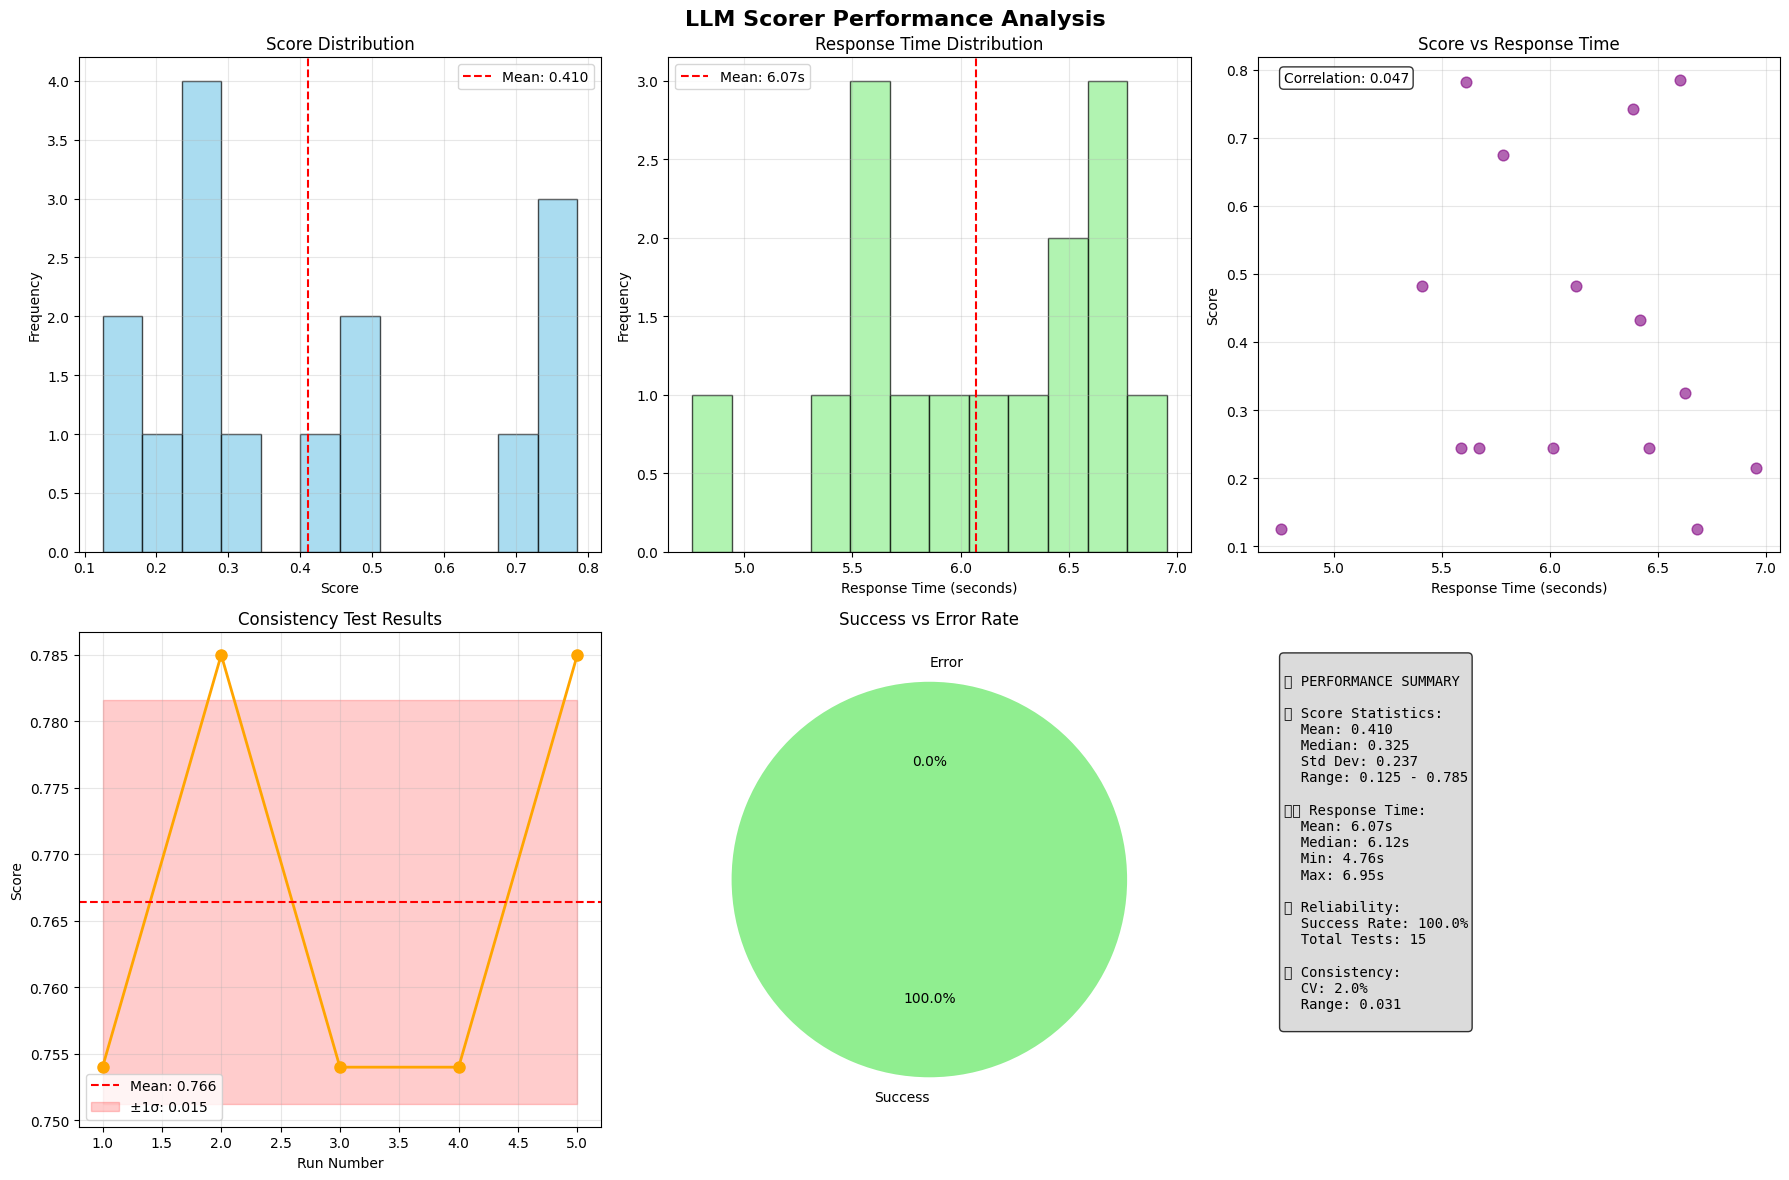


📊 Visualization complete!

🎉 LLM Scorer testing finished successfully!


NameError: name 'components_available' is not defined

In [6]:
# Comprehensive performance visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('LLM Scorer Performance Analysis', fontsize=16, fontweight='bold')

# 1. Score Distribution
axes[0, 0].hist(df_results['scores'], bins=12, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Score Distribution')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_results['scores'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {df_results["scores"].mean():.3f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Response Time Distribution
axes[0, 1].hist(df_results['response_times'], bins=12, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Response Time Distribution')
axes[0, 1].set_xlabel('Response Time (seconds)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df_results['response_times'].mean(), color='red', linestyle='--',
                  label=f'Mean: {df_results["response_times"].mean():.2f}s')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Score vs Response Time Scatter
successful_results = df_results[df_results['errors'].isna()]
axes[0, 2].scatter(successful_results['response_times'], successful_results['scores'], 
                  alpha=0.6, color='purple', s=60)
axes[0, 2].set_title('Score vs Response Time')
axes[0, 2].set_xlabel('Response Time (seconds)')
axes[0, 2].set_ylabel('Score')
axes[0, 2].grid(True, alpha=0.3)

# Add correlation if we have data
if len(successful_results) > 1:
    correlation = np.corrcoef(successful_results['response_times'], successful_results['scores'])[0, 1]
    axes[0, 2].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                   transform=axes[0, 2].transAxes, 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 4. Consistency Test Results
if consistency_scores:
    axes[1, 0].plot(range(1, len(consistency_scores) + 1), consistency_scores, 
                   'o-', linewidth=2, markersize=8, color='orange')
    axes[1, 0].set_title('Consistency Test Results')
    axes[1, 0].set_xlabel('Run Number')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].axhline(np.mean(consistency_scores), color='red', linestyle='--',
                      label=f'Mean: {np.mean(consistency_scores):.3f}')
    axes[1, 0].fill_between(range(1, len(consistency_scores) + 1),
                           np.mean(consistency_scores) - np.std(consistency_scores),
                           np.mean(consistency_scores) + np.std(consistency_scores),
                           alpha=0.2, color='red', label=f'±1σ: {np.std(consistency_scores):.3f}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No consistency data', ha='center', va='center', 
                   transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Consistency Test Results')

# 5. Success Rate Pie Chart
error_count = len(df_results[df_results['errors'].notna()])
success_count = len(df_results[df_results['errors'].isna()])
if success_count + error_count > 0:
    labels = ['Success', 'Error']
    sizes = [success_count, error_count]
    colors = ['lightgreen', 'lightcoral']
    axes[1, 1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[1, 1].set_title('Success vs Error Rate')
else:
    axes[1, 1].text(0.5, 0.5, 'No test data', ha='center', va='center')
    axes[1, 1].set_title('Success vs Error Rate')

# 6. Performance Summary
axes[1, 2].axis('off')
summary_text = f"""
📊 PERFORMANCE SUMMARY

🎯 Score Statistics:
  Mean: {df_results['scores'].mean():.3f}
  Median: {df_results['scores'].median():.3f}
  Std Dev: {df_results['scores'].std():.3f}
  Range: {df_results['scores'].min():.3f} - {df_results['scores'].max():.3f}

⏱️ Response Time:
  Mean: {df_results['response_times'].mean():.2f}s
  Median: {df_results['response_times'].median():.2f}s
  Min: {df_results['response_times'].min():.2f}s
  Max: {df_results['response_times'].max():.2f}s

✅ Reliability:
  Success Rate: {success_count/(success_count + error_count)*100:.1f}%
  Total Tests: {len(df_results)}
"""

if consistency_scores:
    cv = np.std(consistency_scores)/np.mean(consistency_scores)*100 if np.mean(consistency_scores) > 0 else 0
    summary_text += f"""
🎯 Consistency:
  CV: {cv:.1f}%
  Range: {max(consistency_scores) - min(consistency_scores):.3f}
"""

axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes, 
               fontsize=10, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n📊 Visualization complete!")
print(f"\n🎉 LLM Scorer testing finished successfully!")
if not components_available:
    print("⚠️ Note: Tests were run with mock components. Install actual LLM components for real testing.")